In [37]:
import os

path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist"
print(os.listdir(path))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [38]:
import pandas as pd
import torch

train_df = pd.read_csv(path + "/fashion-mnist_train.csv")
test_df = pd.read_csv(path + "/fashion-mnist_test.csv")

In [40]:
X_train = train_df.iloc[:, 1:].values / 255.0
X_test = test_df.iloc[:, 1:].values / 255.0

X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [42]:
def add_noise(x):
    noise = torch.randn_like(x) * 0.15   
    return torch.clamp(x + noise, 0., 1.)

In [43]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=128
)

In [44]:
import torch.nn as nn

class DAE_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 → 14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14 → 7
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),  # 7 → 14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 2, stride=2),   # 14 → 28
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [45]:
model = DAE_CNN()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        img = batch[0]

        noisy = add_noise(img)

        output = model(noisy)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 10.9180
Epoch 2, Loss: 4.0302
Epoch 3, Loss: 3.5331
Epoch 4, Loss: 3.3109
Epoch 5, Loss: 3.1685
Epoch 6, Loss: 3.0683
Epoch 7, Loss: 2.9894
Epoch 8, Loss: 2.9282
Epoch 9, Loss: 2.8727
Epoch 10, Loss: 2.8312


In [29]:
model.eval()

noisy_test = add_noise(X_test)
outputs = model(noisy_test).detach()

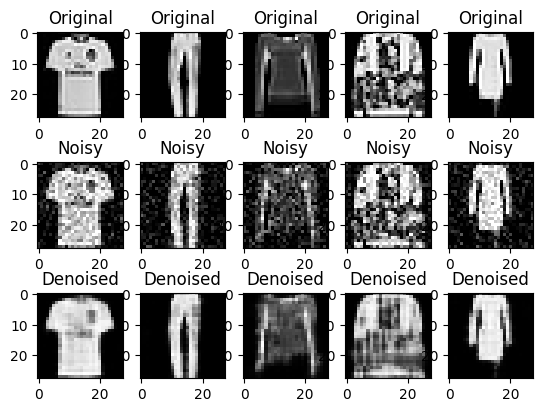

In [30]:
import matplotlib.pyplot as plt

for i in range(5):
    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[i][0], cmap='gray')
    plt.title("Original")

    # Noisy
    plt.subplot(3,5,i+6)
    plt.imshow(noisy_test[i][0], cmap='gray')
    plt.title("Noisy")

    # Denoised
    plt.subplot(3,5,i+11)
    plt.imshow(outputs[i][0], cmap='gray')
    plt.title("Denoised")

plt.show()